In [ ]:
#1. Loading the Taxis Dataset

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Load the dataset
df = sns.load_dataset("taxis")
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [ ]:
# 2.Handling Missing Values
    # Check for missing values in each column
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [ ]:
# Impute missing values

# Impute categorical columns using mode (payment method)
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])

# Impute numerical columns using mean (passenger count)
df["passengers"] = df["passengers"].fillna(df["passengers"].mean())

# Remove rows with missing values in critical columns (locations)
df = df.dropna(
    subset=["pickup_borough", "dropoff_borough", "pickup_zone", "dropoff_zone"]
)

# Ensure pickup column is converted to datetime format
df["pickup"] = pd.to_datetime(df["pickup"])


print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


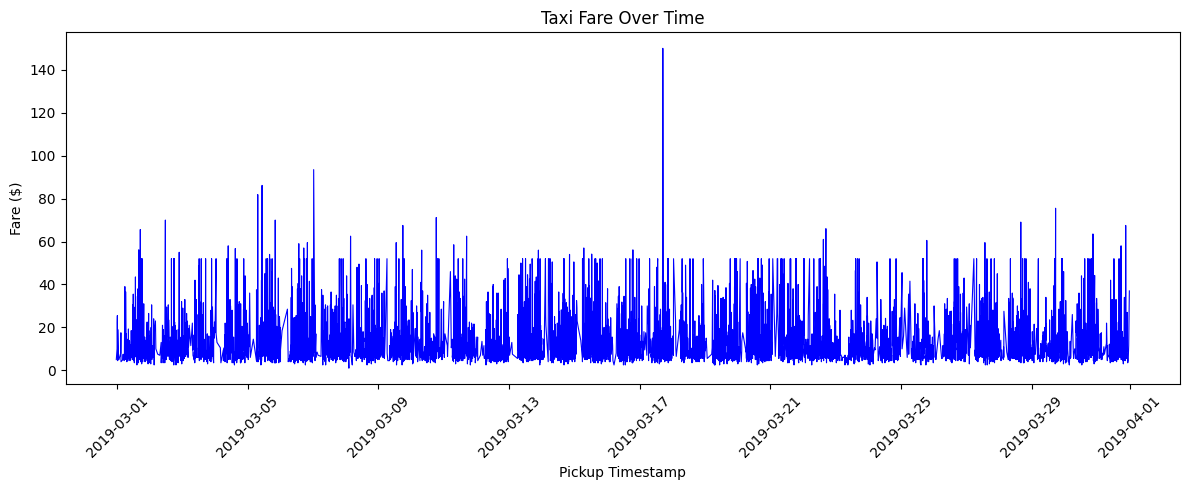

In [ ]:
# 3. Visualizations using Matplotlib/Pandas Plot

# Line chart

# Sort by pickup timestamp to plot sequentially over time
df_time = df.sort_values("pickup")

plt.figure(figsize=(12, 5))
plt.plot(df_time["pickup"], df_time["fare"], color="blue", linewidth=0.8)
plt.title("Taxi Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

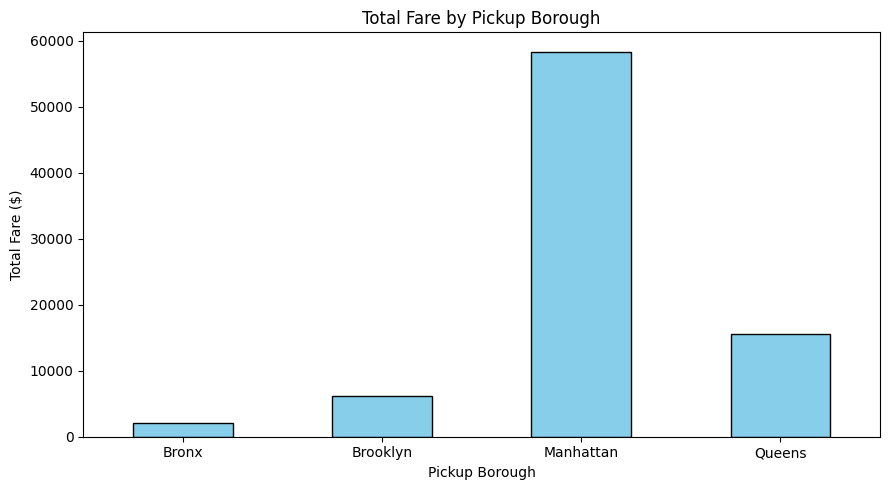

In [ ]:
# ★ Bar Chart

total_fare_borough = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(9, 5))
total_fare_borough.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

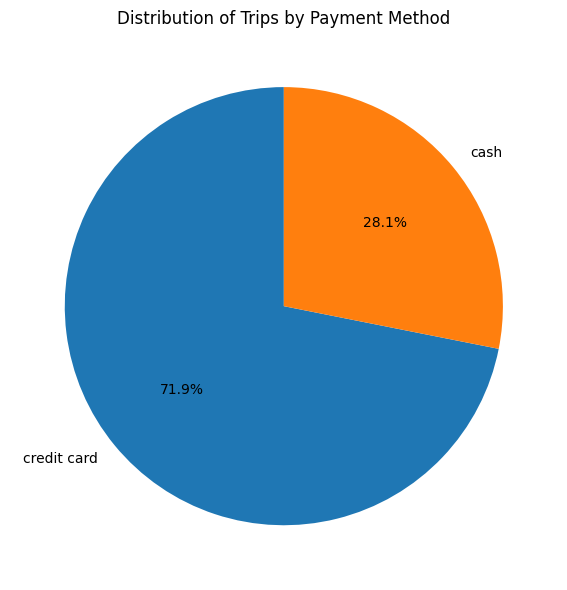

In [ ]:
# ★ Pie Chart

payment_distribution = df["payment"].value_counts()

plt.figure(figsize=(6, 6))
payment_distribution.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90)
plt.title("Distribution of Trips by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()


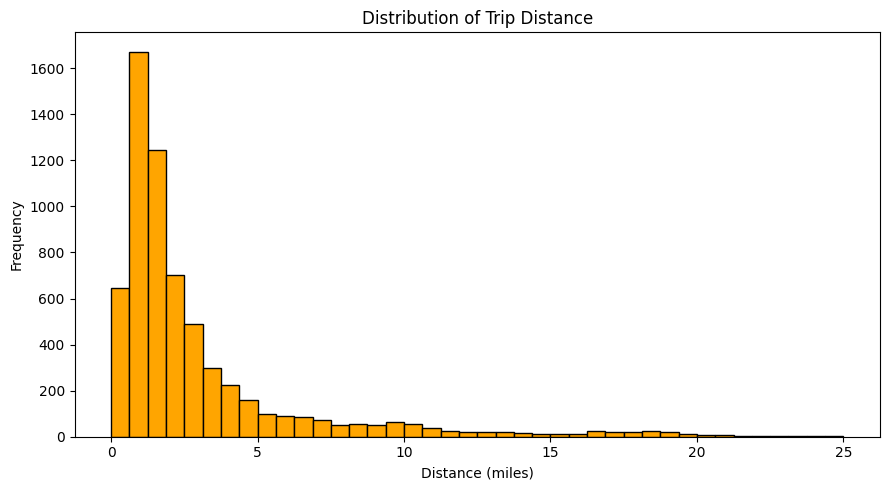

In [ ]:
# ★ Histogram

plt.figure(figsize=(9, 5))
plt.hist(
    df["distance"],
    bins=40,
    color="orange",
    edgecolor="black",
    range=(0, 25),
)
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

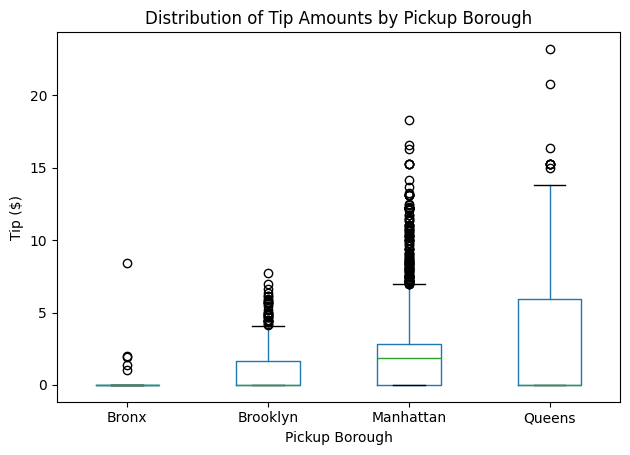

In [ ]:
# ★ Box Plot

plt.figure(figsize=(9, 5))
df.boxplot(column="tip", by="pickup_borough", grid=False)
plt.title("Distribution of Tip Amounts by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

**Visualizations using Seaborn:**

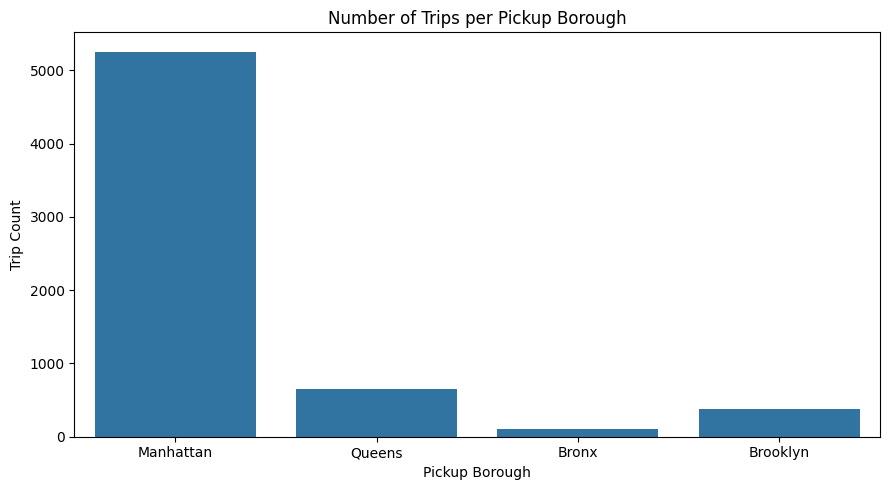

In [ ]:
# ★ Count Plot

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="pickup_borough")
plt.title("Number of Trips per Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

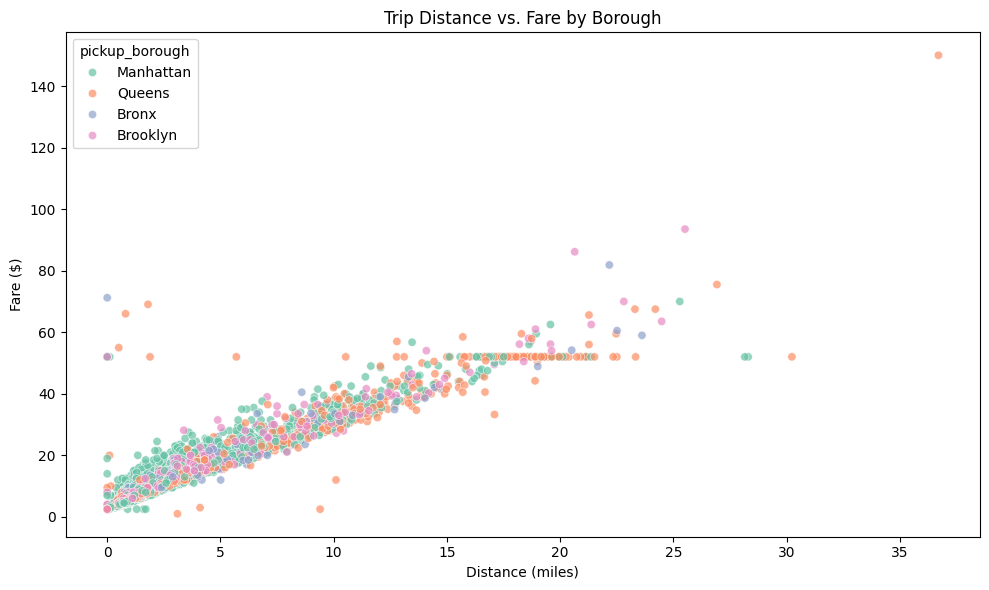

In [ ]:
# ★ Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.7,
    palette="Set2",
)
plt.title("Trip Distance vs. Fare by Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()

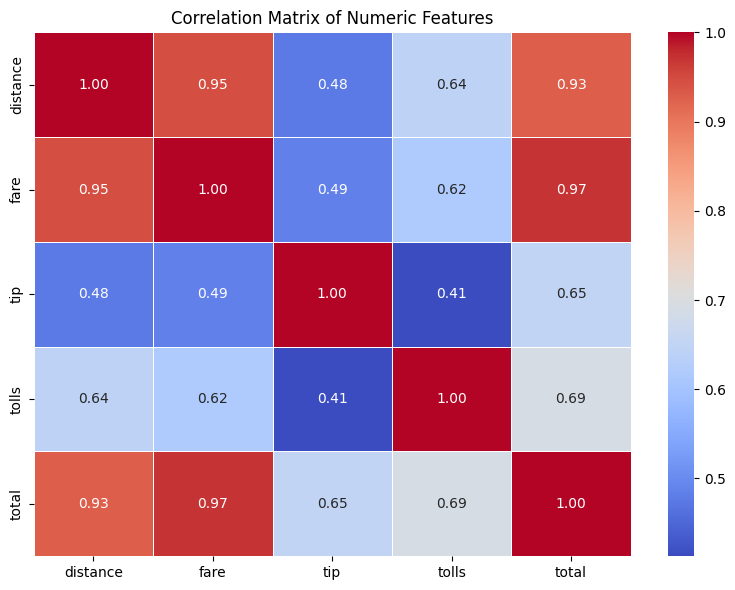

In [ ]:
# ★ Heatmap

numeric_cols = ["distance", "fare", "tip", "tolls", "total"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

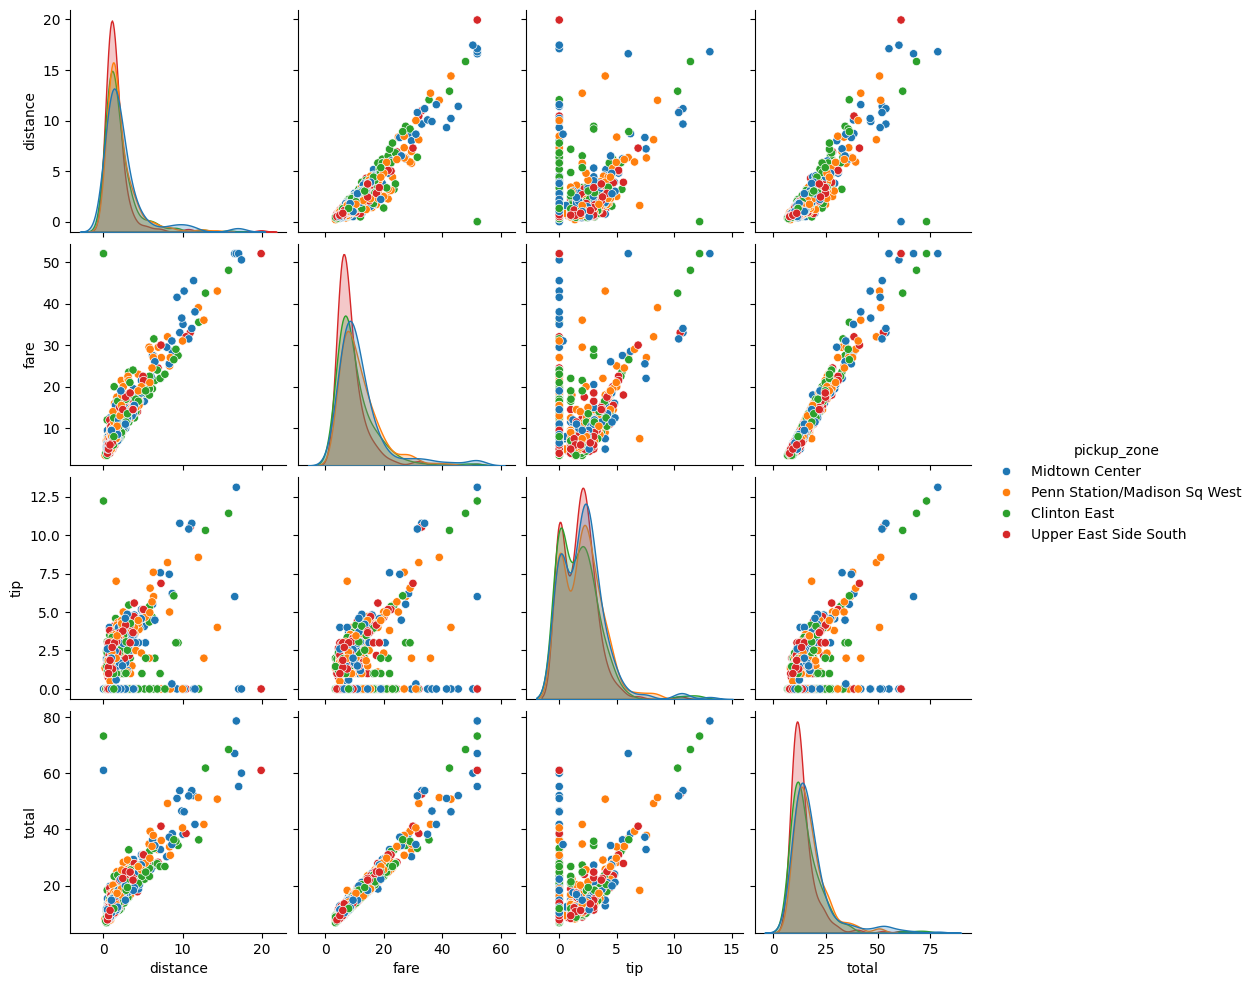

In [ ]:
# ★ Pair Plot

# Select top 4 zones to keep pairplot readable and fast
top_zones = df["pickup_zone"].value_counts().nlargest(4).index
df_sample = df[df["pickup_zone"].isin(top_zones)]

sns.pairplot(
    data=df_sample,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone",
    palette="tab10",
    diag_kind="kde",
)
plt.show()

/tmp/ipykernel_2064/2646650899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


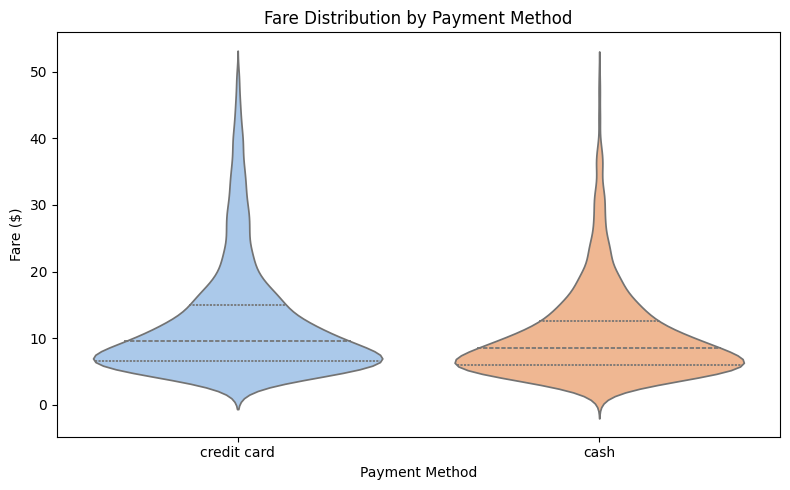

In [ ]:
# ★ Violin Plot

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df[df["fare"] <= 50],
    x="payment",
    y="fare",
    palette="pastel",
    inner="quartile",
)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()